In [1]:
# ===========================================
# PHẦN 1: IMPORT LIBRARIES
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

# Style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12
RANDOM_STATE = 42


In [2]:
# ===========================================
# PHẦN 2: LOAD DATA
# ===========================================
print("=" * 50)
print("LOADING DATA...")
print("=" * 50)

ohlc = pd.read_csv("data/ohlc.csv", parse_dates=["date"])
fundamental = pd.read_csv("data/fundamental.csv")
news = pd.read_csv("data/news.csv", parse_dates=["date"])

ohlc = ohlc.sort_values(["mack", "date"])
fundamental = fundamental.sort_values(["mack", "nam", "quy"])
news = news.sort_values(["mack", "date"])

print(f"OHLC shape: {ohlc.shape}")
print(f"Fundamental shape: {fundamental.shape}")
print(f"News shape: {news.shape}")

LOADING DATA...
OHLC shape: (144176, 7)
Fundamental shape: (2265, 11)
News shape: (35481, 5)


In [3]:
# ===========================================
# PHẦN 3: TECHNICAL INDICATORS
# ===========================================
print("\n" + "=" * 50)
print("COMPUTING TECHNICAL INDICATORS...")
print("=" * 50)

close = ohlc.groupby("mack")["close"]
volume = ohlc.groupby("mack")["volume"]

# SMA - Simple Moving Averages
ohlc["sma_10"] = close.transform(lambda x: x.rolling(10).mean())
ohlc["sma_20"] = close.transform(lambda x: x.rolling(20).mean())
ohlc["sma_50"] = close.transform(lambda x: x.rolling(50).mean())

# EMA - Exponential Moving Averages  
ohlc["ema_10"] = close.transform(lambda x: x.ewm(span=10, adjust=False).mean())
ohlc["ema_20"] = close.transform(lambda x: x.ewm(span=20, adjust=False).mean())

# RSI - Relative Strength Index
def compute_rsi(x, window=14):
    delta = x.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(window).mean() / loss.rolling(window).mean()
    return 100 - (100 / (1 + rs))

ohlc["rsi"] = close.transform(compute_rsi)

# Returns
ohlc["return"] = close.pct_change()

# MACD
ema_12 = close.transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema_26 = close.transform(lambda x: x.ewm(span=26, adjust=False).mean())
ohlc["macd"] = ema_12 - ema_26
ohlc["macd_signal"] = ohlc.groupby("mack")["macd"].transform(
    lambda x: x.ewm(span=9, adjust=False).mean()
)
ohlc["macd_hist"] = ohlc["macd"] - ohlc["macd_signal"]

# Volatility
ohlc["volatility_20"] = ohlc.groupby("mack")["return"].transform(
    lambda x: x.rolling(20).std()
)

# Volume Ratio (mới thêm)
ohlc["volume_ma_20"] = volume.transform(lambda x: x.rolling(20).mean())
ohlc["volume_ratio"] = ohlc["volume"] / ohlc["volume_ma_20"]

print("✓ Technical indicators computed successfully")
print(f"New columns: sma_10, sma_20, sma_50, ema_10, ema_20, rsi, return, macd, macd_signal, macd_hist, volatility_20, volume_ratio")



COMPUTING TECHNICAL INDICATORS...
✓ Technical indicators computed successfully
New columns: sma_10, sma_20, sma_50, ema_10, ema_20, rsi, return, macd, macd_signal, macd_hist, volatility_20, volume_ratio


In [4]:
# ===========================================
# PHẦN 4: FUNDAMENTAL DAILY
# ===========================================
print("\n" + "=" * 50)
print("PROCESSING FUNDAMENTAL DATA...")
print("=" * 50)

fundamental["date"] = (
    pd.to_datetime(
        dict(year=fundamental["nam"], month=fundamental["quy"] * 3, day=1)
    ) + pd.offsets.MonthEnd(0)
)

fundamental_features = [
    "eps", "roe", "roa", "pb", "pe",
    "lnst_yoy", "nophaitra_vcsh", "vonhoa_tts"
]

fundamental_daily = (
    fundamental.sort_values(["mack", "date"])
    .set_index("date")
    .groupby("mack")[fundamental_features]
    .resample("D")
    .ffill()
    .reset_index()
)
print("✓ Fundamental data processed")


PROCESSING FUNDAMENTAL DATA...
✓ Fundamental data processed


In [5]:
# ===========================================
# PHẦN 5: SENTIMENT ANALYSIS (GIẢ ĐỊNH ĐÃ CÓ)
# ===========================================
print("\n" + "=" * 50)
print("PROCESSING SENTIMENT DATA...")
print("=" * 50)

# Giả sử news đã có sentiment scores từ PhoBERT
# Nếu chưa có, cần chạy PhoBERT sentiment analysis trước
if "sent_score" not in news.columns:
    print("⚠️ Sentiment columns not found. Creating dummy sentiment...")
    np.random.seed(RANDOM_STATE)
    news["sent_pos"] = np.random.uniform(0.1, 0.5, len(news))
    news["sent_neu"] = np.random.uniform(0.2, 0.6, len(news))
    news["sent_neg"] = np.random.uniform(0.1, 0.4, len(news))
    news["sent_score"] = news["sent_pos"] - news["sent_neg"]

sent_daily = (
    news.groupby(["mack", "date"])
    .agg({
        "sent_pos": "mean",
        "sent_neu": "mean", 
        "sent_neg": "mean",
        "sent_score": "mean"
    }).reset_index()
)
print("✓ Sentiment data processed")


PROCESSING SENTIMENT DATA...
⚠️ Sentiment columns not found. Creating dummy sentiment...
✓ Sentiment data processed


In [6]:
# ===========================================
# PHẦN 6: MERGE DATA
# ===========================================
print("\n" + "=" * 50)
print("MERGING DATA...")
print("=" * 50)

df = (
    ohlc
    .merge(fundamental_daily, on=["mack", "date"], how="left")
    .merge(sent_daily, on=["mack", "date"], how="left")
)

df = df.sort_values(["mack", "date"]).reset_index(drop=True)
print(f"Merged shape: {df.shape}")


MERGING DATA...
Merged shape: (144176, 32)


In [7]:
# ===========================================
# PHẦN 7: NaN HANDLING
# ===========================================
print("\n" + "=" * 50)
print("HANDLING MISSING VALUES...")
print("=" * 50)

fund_cols = [
    "eps", "roe", "roa", "pb", "pe",
    "lnst_yoy", "nophaitra_vcsh", "vonhoa_tts"
]
sent_cols = ["sent_score"]

# Forward fill
df[fund_cols] = df.groupby("mack", group_keys=False)[fund_cols].transform(lambda x: x.ffill())
df[sent_cols] = df.groupby("mack", group_keys=False)[sent_cols].transform(lambda x: x.ffill(limit=5))

# Drop remaining NaN
before = df.shape[0]
df = df.dropna(subset=fund_cols + sent_cols).reset_index(drop=True)
after = df.shape[0]

print(f"✓ Rows before: {before:,}")
print(f"✓ Rows after: {after:,}")
print(f"✓ Dropped: {before - after:,}")


HANDLING MISSING VALUES...
✓ Rows before: 144,176
✓ Rows after: 72,464
✓ Dropped: 71,712


In [8]:
# ===========================================
# PHẦN 8: SECTOR MAPPING
# ===========================================
print("\n" + "=" * 50)
print("MAPPING SECTORS...")
print("=" * 50)

sector_map = {
    # Dầu khí
    "HPG": "Dầu khí", "HSG": "Dầu khí", "NKG": "Dầu khí", "PVT": "Dầu khí", "PVD": "Dầu khí",
    # Nguyên vật liệu
    "GVR": "Nguyên vật liệu", "PHR": "Nguyên vật liệu", "DGC": "Nguyên vật liệu",
    "DCM": "Nguyên vật liệu", "DPM": "Nguyên vật liệu", "BMP": "Nguyên vật liệu",
    "VGC": "Nguyên vật liệu", "HT1": "Nguyên vật liệu",
    # Công nghiệp
    "GEE": "Công nghiệp", "GEX": "Công nghiệp", "HDG": "Công nghiệp", "PC1": "Công nghiệp",
    "REE": "Công nghiệp", "MSN": "Công nghiệp", "VIC": "Công nghiệp", "GMD": "Công nghiệp",
    "VSC": "Công nghiệp", "SCS": "Công nghiệp", "VJC": "Công nghiệp", "VCG": "Công nghiệp",
    "CII": "Công nghiệp", "HHV": "Công nghiệp", "PTB": "Công nghiệp", "CTD": "Công nghiệp",
    "VTP": "Công nghiệp",
    # Hàng tiêu dùng
    "TLG": "Hàng tiêu dùng", "VNM": "Hàng tiêu dùng", "HAG": "Hàng tiêu dùng",
    "SBT": "Hàng tiêu dùng", "KDC": "Hàng tiêu dùng", "VHC": "Hàng tiêu dùng",
    "DBC": "Hàng tiêu dùng", "ANV": "Hàng tiêu dùng", "PAN": "Hàng tiêu dùng",
    "SAB": "Hàng tiêu dùng", "PNJ": "Hàng tiêu dùng",
    # Dược phẩm & Y tế
    "IMP": "Dược phẩm và Y tế",
    # Dịch vụ tiêu dùng
    "MWG": "Dịch vụ Tiêu dùng", "FRT": "Dịch vụ Tiêu dùng", "PLX": "Dịch vụ Tiêu dùng",
    "TCH": "Dịch vụ Tiêu dùng", "DGW": "Dịch vụ Tiêu dùng",
    # Viễn thông
    "CTR": "Viễn thông",
    # Tiện ích cộng đồng
    "POW": "Tiện ích cộng đồng", "NT2": "Tiện ích cộng đồng",
    "PPC": "Tiện ích cộng đồng", "GAS": "Tiện ích cộng đồng", "BWE": "Tiện ích cộng đồng",
    # Tài chính
    "HDC": "Tài chính", "VHM": "Tài chính", "VRE": "Tài chính", "BCM": "Tài chính",
    "KDH": "Tài chính", "KBC": "Tài chính", "DXG": "Tài chính", "PDR": "Tài chính",
    "VPI": "Tài chính", "SJS": "Tài chính", "NLG": "Tài chính", "DIG": "Tài chính",
    "SIP": "Tài chính", "KOS": "Tài chính", "DXS": "Tài chính", "SZC": "Tài chính",
    "SSI": "Tài chính", "VIX": "Tài chính", "VND": "Tài chính", "VCI": "Tài chính",
    "HCM": "Tài chính", "FTS": "Tài chính", "BSI": "Tài chính", "DSE": "Tài chính",
    "CTS": "Tài chính", "BVH": "Tài chính", "EVF": "Tài chính",
    # Ngân hàng
    "VCB": "Ngân hàng", "CTG": "Ngân hàng", "BID": "Ngân hàng", "TCB": "Ngân hàng",
    "VPB": "Ngân hàng", "MBB": "Ngân hàng", "HDB": "Ngân hàng", "LPB": "Ngân hàng",
    "ACB": "Ngân hàng", "STB": "Ngân hàng", "SHB": "Ngân hàng", "VIB": "Ngân hàng",
    "SSB": "Ngân hàng", "TPB": "Ngân hàng", "EIB": "Ngân hàng", "MSB": "Ngân hàng",
    "OCB": "Ngân hàng", "NAB": "Ngân hàng",
    # Công nghệ thông tin
    "FPT": "Công nghệ thông tin", "CMG": "Công nghệ thông tin"
}

df["sector"] = df["mack"].map(sector_map)
df = df.dropna(subset=["sector"])
print(f"✓ Number of sectors: {df['sector'].nunique()}")
print(f"✓ Sectors: {sorted(df['sector'].unique())}")




MAPPING SECTORS...
✓ Number of sectors: 11
✓ Sectors: ['Công nghiệp', 'Công nghệ thông tin', 'Dược phẩm và Y tế', 'Dầu khí', 'Dịch vụ Tiêu dùng', 'Hàng tiêu dùng', 'Nguyên vật liệu', 'Ngân hàng', 'Tiện ích cộng đồng', 'Tài chính', 'Viễn thông']


In [9]:
# ===========================================
# PHẦN 9: CREATE TARGET
# ===========================================
print("\n" + "=" * 50)
print("CREATING TARGET VARIABLE...")
print("=" * 50)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["mack", "date"]).reset_index(drop=True)

# Target: 1 if return > 0.5%, 0 if return < -0.5%
df["return_1d"] = df.groupby("mack")["close"].pct_change().shift(-1)
df["target"] = np.where(
    df["return_1d"] > 0.005, 1,
    np.where(df["return_1d"] < -0.005, 0, np.nan)
)
df = df.dropna(subset=["target"]).reset_index(drop=True)
df["target"] = df["target"].astype(int)

print(f"✓ Final shape: {df.shape}")
print(f"✓ Target distribution:")
print(df["target"].value_counts())


CREATING TARGET VARIABLE...
✓ Final shape: (53153, 35)
✓ Target distribution:
target
1    27716
0    25437
Name: count, dtype: int64



CREATING VISUALIZATIONS...


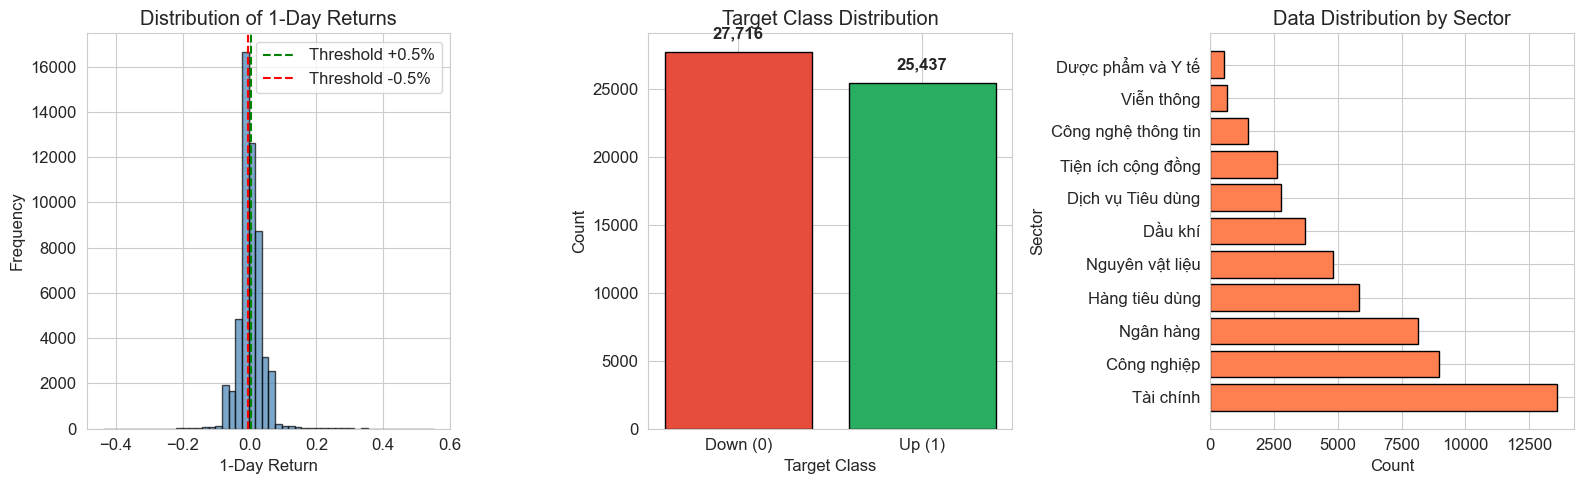

✓ Saved: viz_01_data_distribution.png


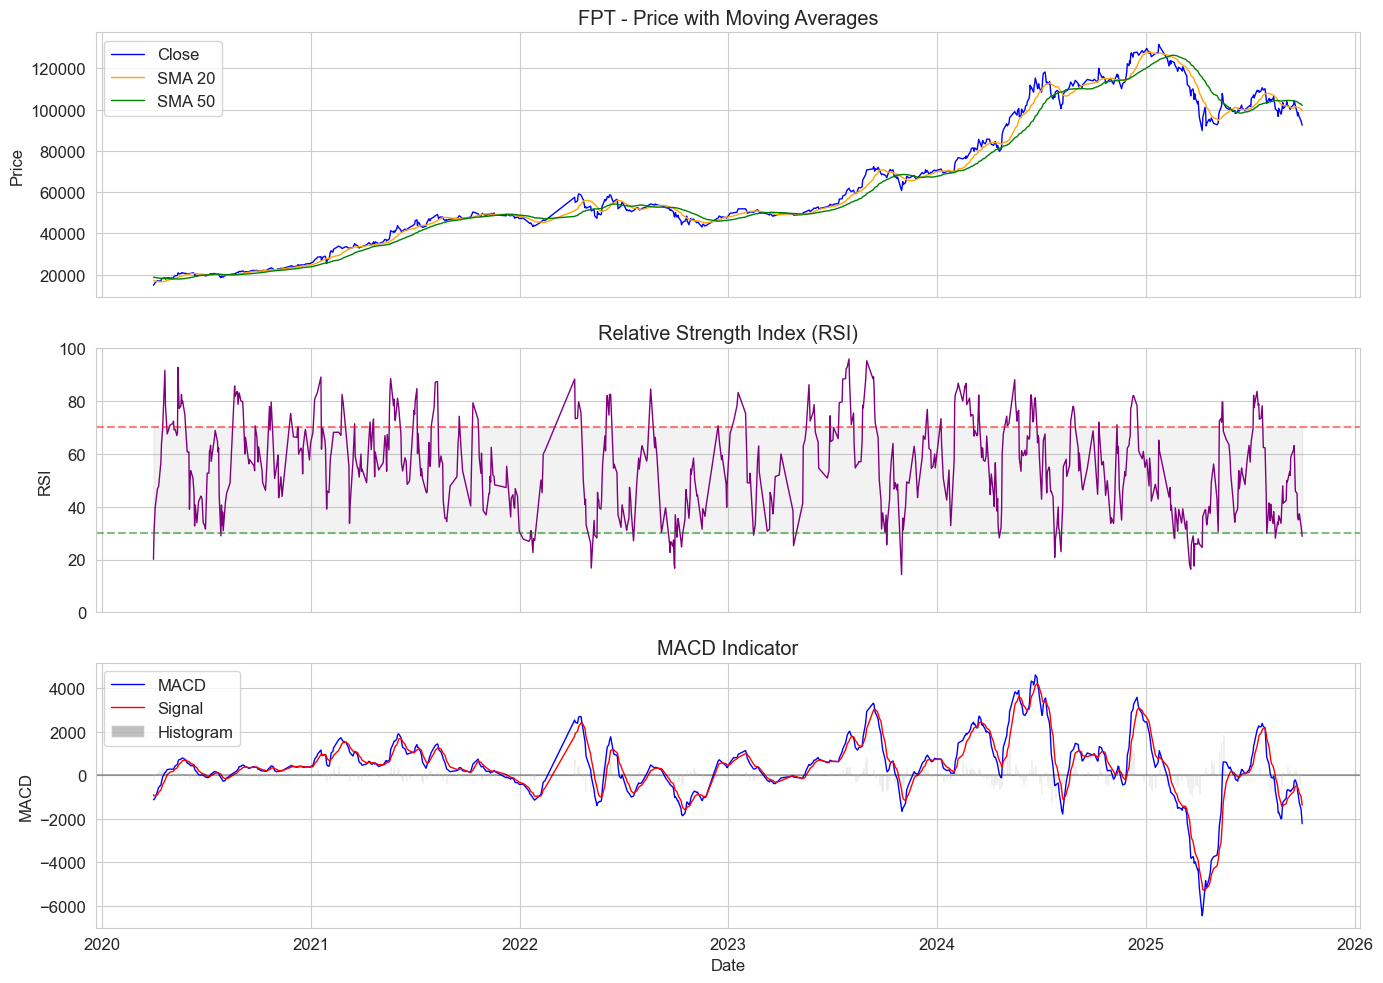

✓ Saved: viz_02_technical_indicators.png


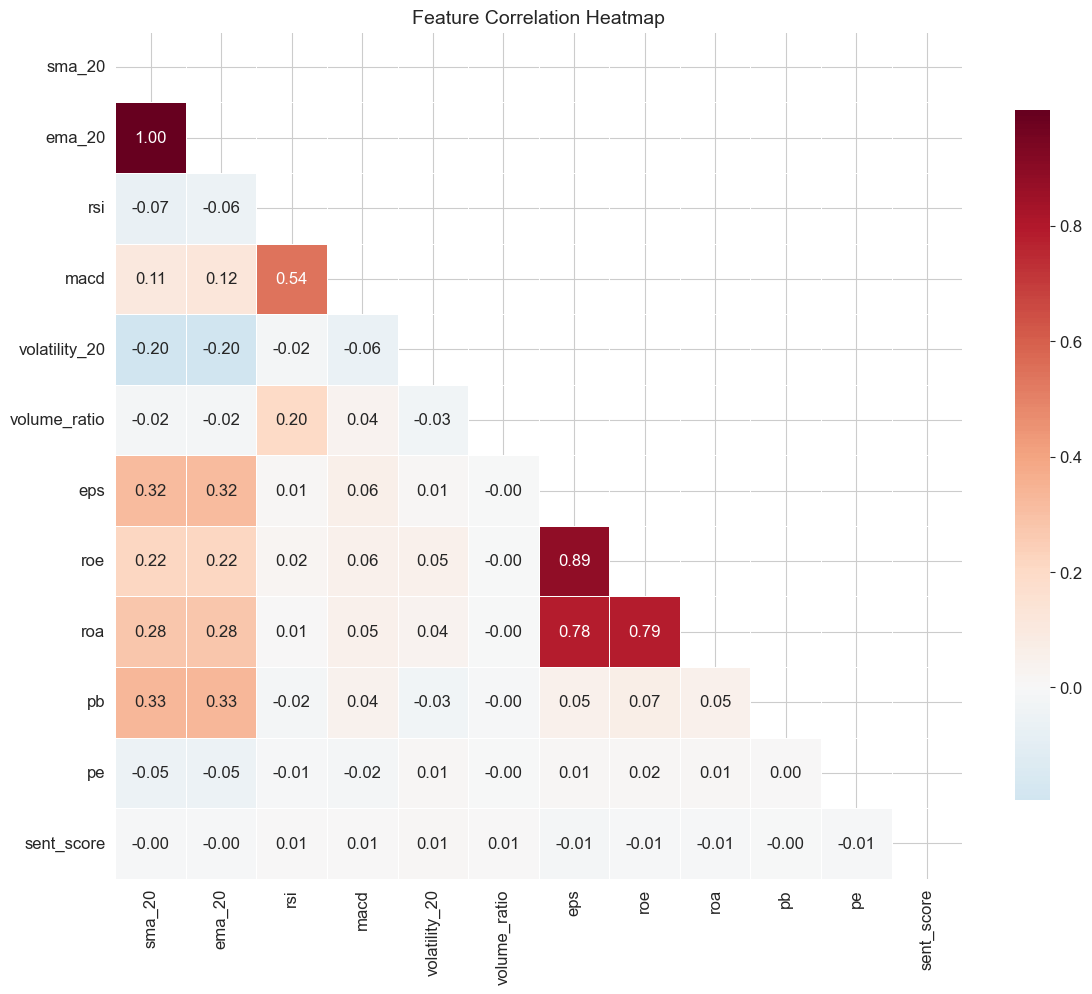

✓ Saved: viz_03_correlation_heatmap.png


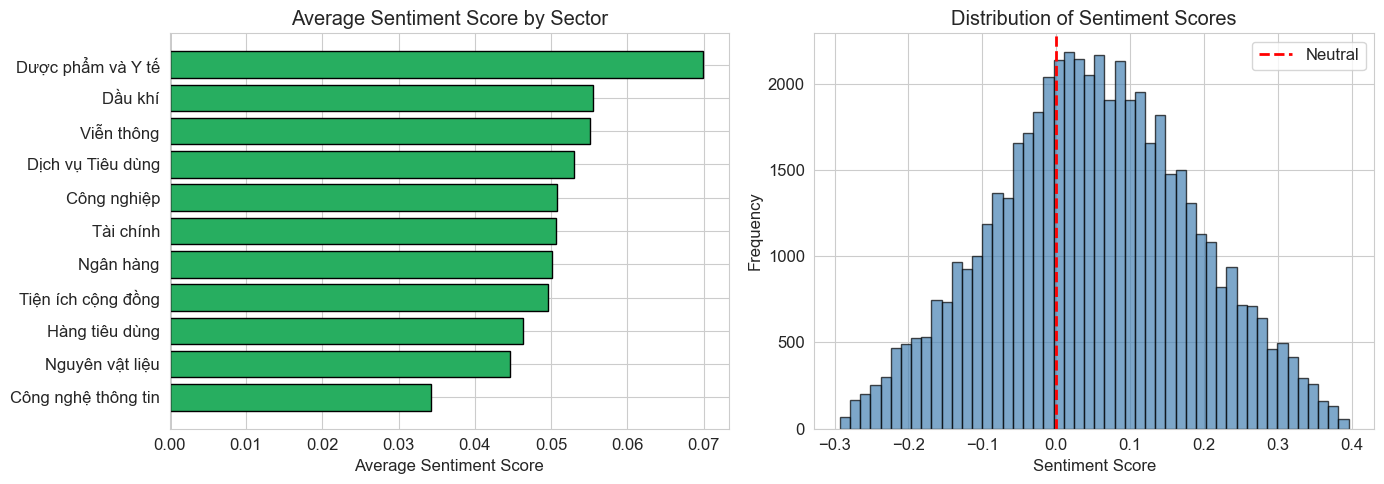

✓ Saved: viz_04_sentiment_distribution.png


In [10]:
# ===========================================
# PHẦN 10: DATA VISUALIZATION
# ===========================================
print("\n" + "=" * 50)
print("CREATING VISUALIZATIONS...")
print("=" * 50)

# ----- 10.1: Distribution of Returns -----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Return distribution
axes[0].hist(df["return_1d"].dropna(), bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(x=0.005, color="green", linestyle="--", label="Threshold +0.5%")
axes[0].axvline(x=-0.005, color="red", linestyle="--", label="Threshold -0.5%")
axes[0].set_xlabel("1-Day Return")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of 1-Day Returns")
axes[0].legend()

# Target class balance
target_counts = df["target"].value_counts()
colors = ["#e74c3c", "#27ae60"]
axes[1].bar(["Down (0)", "Up (1)"], target_counts.values, color=colors, edgecolor="black")
axes[1].set_xlabel("Target Class")
axes[1].set_ylabel("Count")
axes[1].set_title("Target Class Distribution")
for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

# Sector distribution
sector_counts = df["sector"].value_counts()
axes[2].barh(sector_counts.index, sector_counts.values, color="coral", edgecolor="black")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Sector")
axes[2].set_title("Data Distribution by Sector")

plt.tight_layout()
plt.savefig("viz_01_data_distribution.png", dpi=150)
plt.show()
print("✓ Saved: viz_01_data_distribution.png")


# ----- 10.2: Technical Indicators Time Series (Sample) -----
sample_stock = df[df["mack"] == "FPT"].copy()
if len(sample_stock) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Price with SMA
    axes[0].plot(sample_stock["date"], sample_stock["close"], label="Close", color="blue", linewidth=1)
    axes[0].plot(sample_stock["date"], sample_stock["sma_20"], label="SMA 20", color="orange", linewidth=1)
    axes[0].plot(sample_stock["date"], sample_stock["sma_50"], label="SMA 50", color="green", linewidth=1)
    axes[0].set_ylabel("Price")
    axes[0].set_title("FPT - Price with Moving Averages")
    axes[0].legend()
    
    # RSI
    axes[1].plot(sample_stock["date"], sample_stock["rsi"], color="purple", linewidth=1)
    axes[1].axhline(y=70, color="red", linestyle="--", alpha=0.5)
    axes[1].axhline(y=30, color="green", linestyle="--", alpha=0.5)
    axes[1].fill_between(sample_stock["date"], 30, 70, alpha=0.1, color="gray")
    axes[1].set_ylabel("RSI")
    axes[1].set_title("Relative Strength Index (RSI)")
    axes[1].set_ylim(0, 100)
    
    # MACD
    axes[2].plot(sample_stock["date"], sample_stock["macd"], label="MACD", color="blue", linewidth=1)
    axes[2].plot(sample_stock["date"], sample_stock["macd_signal"], label="Signal", color="red", linewidth=1)
    axes[2].bar(sample_stock["date"], sample_stock["macd_hist"], label="Histogram", color="gray", alpha=0.5)
    axes[2].axhline(y=0, color="black", linestyle="-", alpha=0.3)
    axes[2].set_xlabel("Date")
    axes[2].set_ylabel("MACD")
    axes[2].set_title("MACD Indicator")
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig("viz_02_technical_indicators.png", dpi=150)
    plt.show()
    print("✓ Saved: viz_02_technical_indicators.png")


# ----- 10.3: Correlation Heatmap -----
feature_cols = [
    "sma_20", "ema_20", "rsi", "macd", "volatility_20", "volume_ratio",
    "eps", "roe", "roa", "pb", "pe", "sent_score"
]
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("viz_03_correlation_heatmap.png", dpi=150)
plt.show()
print("✓ Saved: viz_03_correlation_heatmap.png")


# ----- 10.4: Sentiment Distribution -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment score by sector
sector_sent = df.groupby("sector")["sent_score"].mean().sort_values()
colors = ["#e74c3c" if x < 0 else "#27ae60" for x in sector_sent.values]
axes[0].barh(sector_sent.index, sector_sent.values, color=colors, edgecolor="black")
axes[0].axvline(x=0, color="black", linestyle="-", linewidth=1)
axes[0].set_xlabel("Average Sentiment Score")
axes[0].set_title("Average Sentiment Score by Sector")

# Sentiment score distribution
axes[1].hist(df["sent_score"], bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=2, label="Neutral")
axes[1].set_xlabel("Sentiment Score")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Sentiment Scores")
axes[1].legend()

plt.tight_layout()
plt.savefig("viz_04_sentiment_distribution.png", dpi=150)
plt.show()
print("✓ Saved: viz_04_sentiment_distribution.png")

In [11]:
# ===========================================
# PHẦN 11: FEATURE GROUPS & MODEL TRAINING
# ===========================================
print("\n" + "=" * 50)
print("TRAINING MODELS...")
print("=" * 50)

# Feature groups
fundamental_features_model = [
    "pe", "pb", "roe", "roa", "eps", "lnst_yoy",
    "vonhoa_tts", "nophaitra_vcsh"
]

technical_features_model = [
    "rsi", "macd", "macd_signal", "macd_hist",
    "sma_20", "ema_20", "volatility_20", "volume_ratio"
]

sentiment_features_model = [
    "sent_score", "sent_pos", "sent_neg"
]

feature_groups = {
    "Model 1 | Fundamental": fundamental_features_model,
    "Model 2 | Technical": technical_features_model,
    "Model 3 | Sentiment": sentiment_features_model,
    "Model 4 | Fund + Tech": fundamental_features_model + technical_features_model,
    "Model 5 | Fund + Sent": fundamental_features_model + sentiment_features_model,
    "Model 6 | Tech + Sent": technical_features_model + sentiment_features_model,
    "Model 7 | All": fundamental_features_model + technical_features_model + sentiment_features_model
}


def train_mlp(df_sector, features, split_date="2023-01-01"):
    """Train MLP classifier with proper date-based split"""
    available_features = [f for f in features if f in df_sector.columns]
    if len(available_features) < 3:
        return None
    
    # Create feature matrix
    X = df_sector[available_features].copy()
    y = df_sector["target"].copy()
    dates = df_sector["date"].values
    
    # Remove NaN
    mask = X.notna().all(axis=1)
    X, y, dates = X[mask], y[mask], dates[mask]
    
    if len(y) < 150 or y.nunique() < 2:
        return None
    
    # Time-based split
    split_dt = pd.to_datetime(split_date)
    train_idx = dates < split_dt
    
    X_train, X_test = X[train_idx], X[~train_idx]
    y_train, y_test = y[train_idx], y[~train_idx]
    
    if len(y_test) < 10 or y_test.nunique() < 2:
        return None
    
    # Pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=600,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=0.1
        ))
    ])
    
    try:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        
        return {
            "Accuracy": accuracy_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_prob),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "y_test": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "model": pipe
        }
    except Exception as e:
        print(f"⚠️ Error: {e}")
        return None


# Training loop
results = []
all_predictions = {}

for sector in sorted(df["sector"].unique()):
    df_sector = df[df["sector"] == sector].copy()
    
    if len(df_sector) < 150:
        continue
    
    for model_name, features in feature_groups.items():
        metrics = train_mlp(df_sector, features)
        if metrics is None:
            continue
        
        results.append({
            "Sector": sector,
            "Model": model_name,
            "Accuracy": metrics["Accuracy"],
            "AUC": metrics["AUC"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1": metrics["F1"],
            "n_train": metrics["n_train"],
            "n_test": metrics["n_test"]
        })
        
        # Store predictions for visualization
        key = f"{sector}_{model_name}"
        all_predictions[key] = {
            "y_test": metrics["y_test"],
            "y_pred": metrics["y_pred"],
            "y_prob": metrics["y_prob"]
        }
    
    print(f"✓ Completed: {sector}")

results_df = pd.DataFrame(results)
print(f"\n✓ Training completed. Total results: {len(results_df)}")



TRAINING MODELS...
✓ Completed: Công nghiệp
✓ Completed: Công nghệ thông tin
✓ Completed: Dược phẩm và Y tế
✓ Completed: Dầu khí
✓ Completed: Dịch vụ Tiêu dùng
✓ Completed: Hàng tiêu dùng
✓ Completed: Nguyên vật liệu
✓ Completed: Ngân hàng
✓ Completed: Tiện ích cộng đồng
✓ Completed: Tài chính
✓ Completed: Viễn thông

✓ Training completed. Total results: 77



CREATING EVALUATION VISUALIZATIONS...


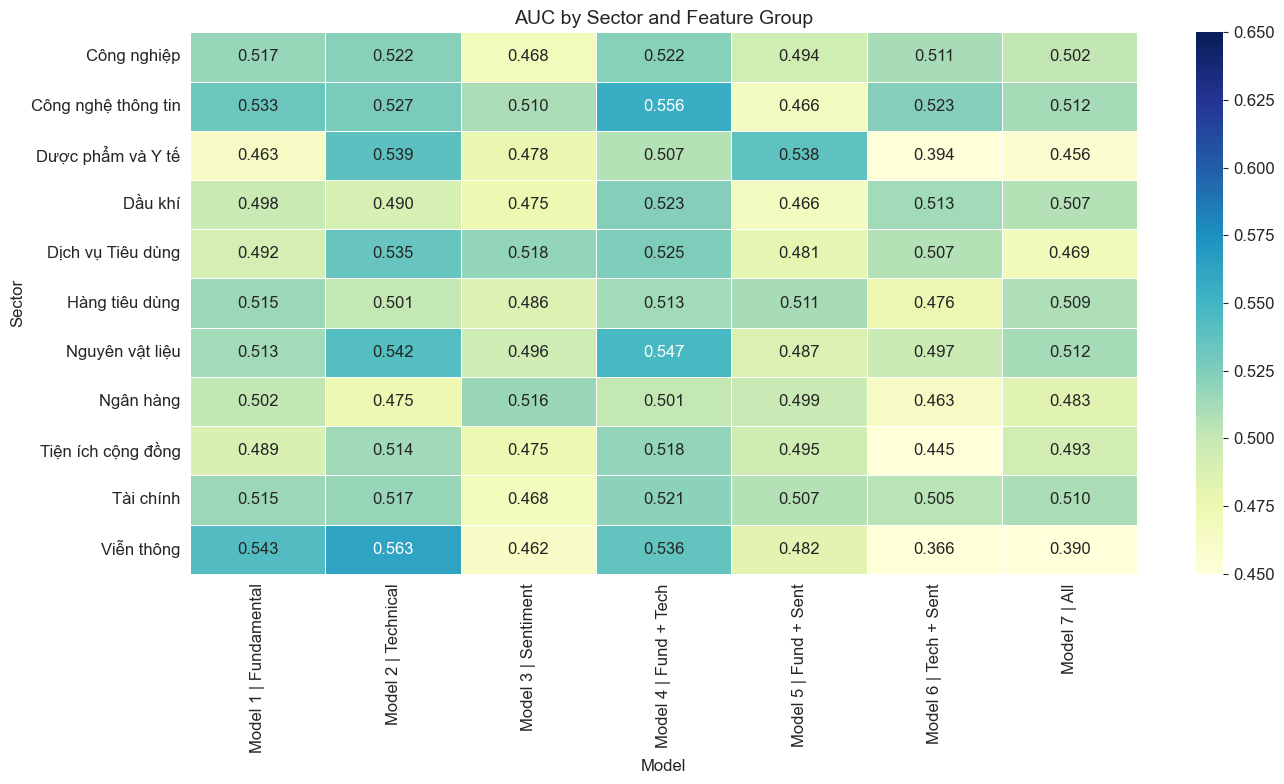

✓ Saved: viz_05_auc_heatmap.png


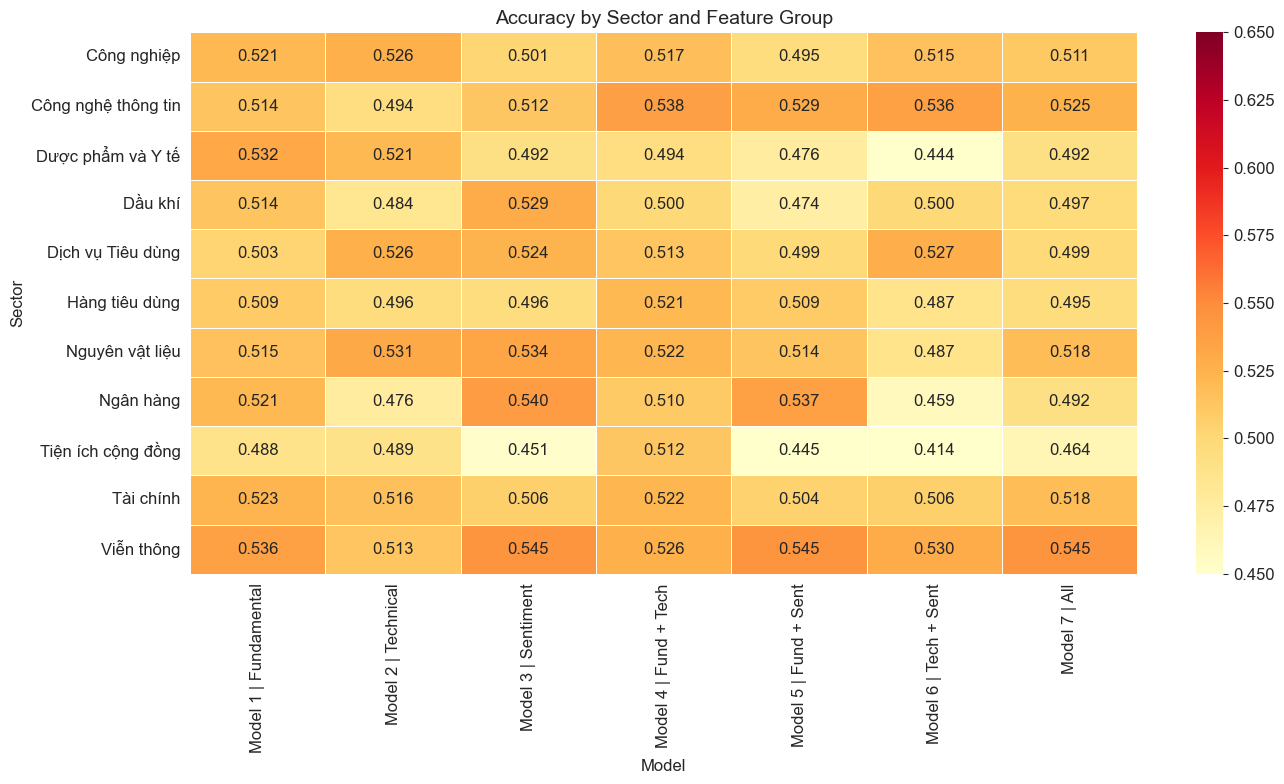

✓ Saved: viz_06_accuracy_heatmap.png


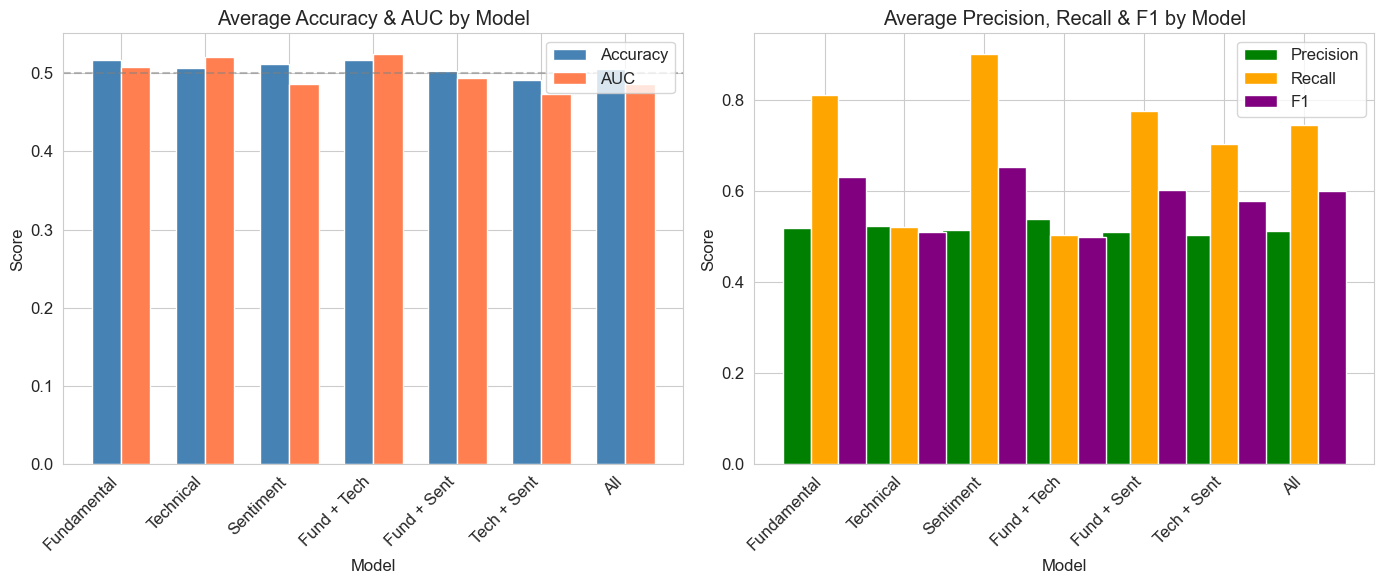

✓ Saved: viz_07_model_comparison.png


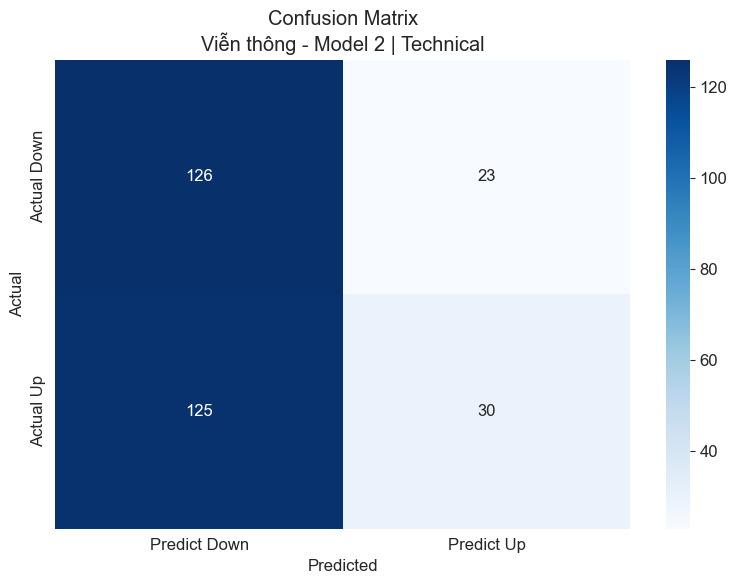

✓ Saved: viz_08_confusion_matrix.png


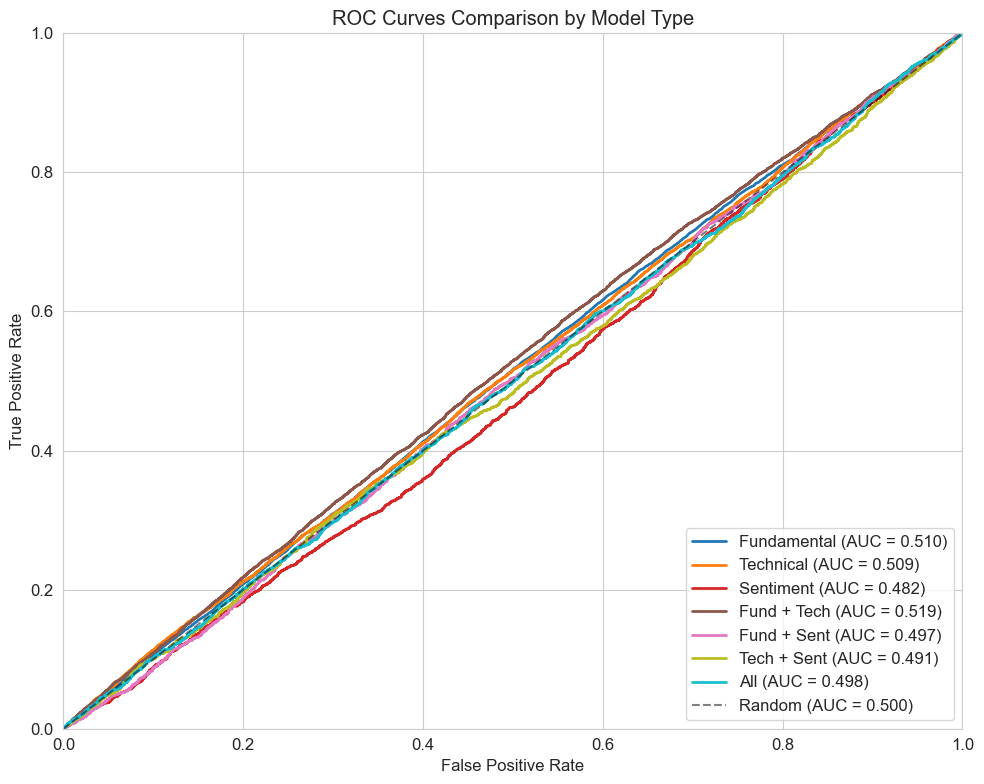

✓ Saved: viz_09_roc_curves.png


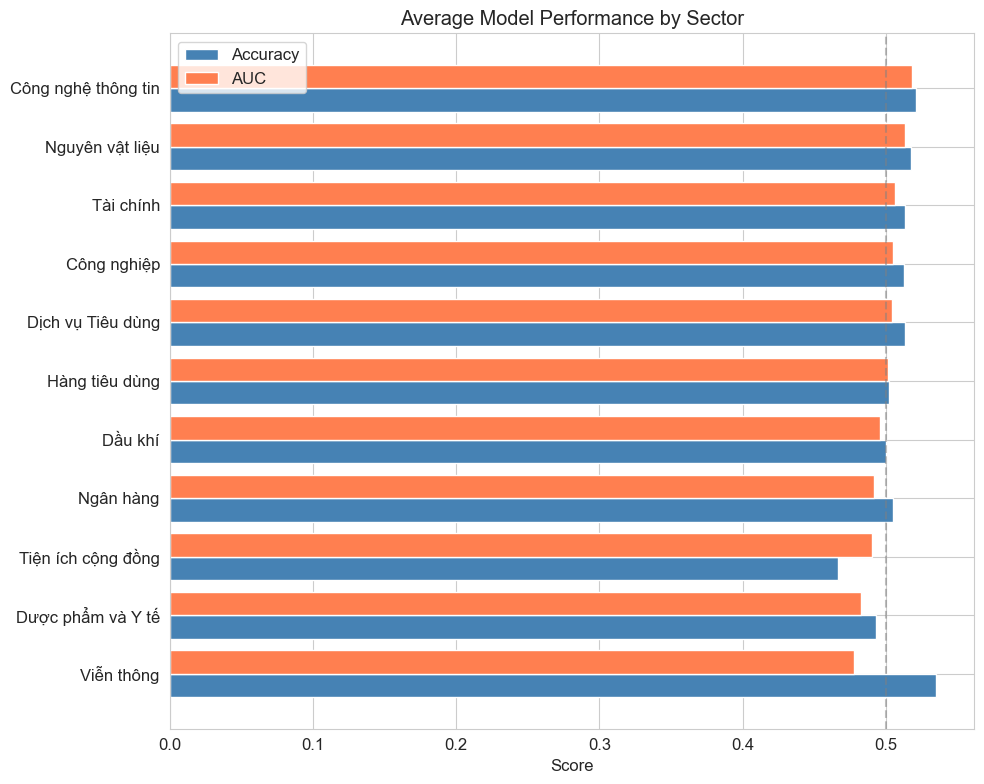

✓ Saved: viz_10_sector_ranking.png


In [12]:
# ===========================================
# PHẦN 12: MODEL EVALUATION VISUALIZATIONS
# ===========================================
print("\n" + "=" * 50)
print("CREATING EVALUATION VISUALIZATIONS...")
print("=" * 50)

# ----- 12.1: AUC Heatmap -----
auc_table = results_df.pivot(
    index="Sector",
    columns="Model",
    values="AUC"
).round(3)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(auc_table, annot=True, cmap="YlGnBu", fmt=".3f",
            linewidths=0.5, ax=ax, vmin=0.45, vmax=0.65)
ax.set_title("AUC by Sector and Feature Group", fontsize=14)
plt.tight_layout()
plt.savefig("viz_05_auc_heatmap.png", dpi=150)
plt.show()
print("✓ Saved: viz_05_auc_heatmap.png")


# ----- 12.2: Accuracy Heatmap -----
acc_table = results_df.pivot(
    index="Sector",
    columns="Model",
    values="Accuracy"
).round(3)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(acc_table, annot=True, cmap="YlOrRd", fmt=".3f",
            linewidths=0.5, ax=ax, vmin=0.45, vmax=0.65)
ax.set_title("Accuracy by Sector and Feature Group", fontsize=14)
plt.tight_layout()
plt.savefig("viz_06_accuracy_heatmap.png", dpi=150)
plt.show()
print("✓ Saved: viz_06_accuracy_heatmap.png")


# ----- 12.3: Model Performance Comparison -----
model_avg = results_df.groupby("Model")[["Accuracy", "AUC", "Precision", "Recall", "F1"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy & AUC comparison
x = np.arange(len(model_avg))
width = 0.35

axes[0].bar(x - width/2, model_avg["Accuracy"], width, label="Accuracy", color="steelblue")
axes[0].bar(x + width/2, model_avg["AUC"], width, label="AUC", color="coral")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Score")
axes[0].set_title("Average Accuracy & AUC by Model")
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.split(" | ")[1] for m in model_avg.index], rotation=45, ha="right")
axes[0].legend()
axes[0].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

# F1, Precision, Recall comparison
axes[1].bar(x - width, model_avg["Precision"], width, label="Precision", color="green")
axes[1].bar(x, model_avg["Recall"], width, label="Recall", color="orange")
axes[1].bar(x + width, model_avg["F1"], width, label="F1", color="purple")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Score")
axes[1].set_title("Average Precision, Recall & F1 by Model")
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.split(" | ")[1] for m in model_avg.index], rotation=45, ha="right")
axes[1].legend()

plt.tight_layout()
plt.savefig("viz_07_model_comparison.png", dpi=150)
plt.show()
print("✓ Saved: viz_07_model_comparison.png")


# ----- 12.4: Confusion Matrix (Sample) -----
# Pick best performing sector-model combination
if len(all_predictions) > 0:
    # Find best AUC
    best_idx = results_df["AUC"].idxmax()
    best_sector = results_df.loc[best_idx, "Sector"]
    best_model = results_df.loc[best_idx, "Model"]
    best_key = f"{best_sector}_{best_model}"
    
    if best_key in all_predictions:
        pred_data = all_predictions[best_key]
        cm = confusion_matrix(pred_data["y_test"], pred_data["y_pred"])
        
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Predict Down", "Predict Up"],
                    yticklabels=["Actual Down", "Actual Up"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"Confusion Matrix\n{best_sector} - {best_model}")
        plt.tight_layout()
        plt.savefig("viz_08_confusion_matrix.png", dpi=150)
        plt.show()
        print("✓ Saved: viz_08_confusion_matrix.png")


# ----- 12.5: ROC Curves Comparison -----
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC for each model (averaged across sectors)
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_groups)))
for i, model_name in enumerate(feature_groups.keys()):
    # Collect all predictions for this model
    model_y_test = []
    model_y_prob = []
    
    for key, pred_data in all_predictions.items():
        if model_name in key:
            model_y_test.extend(pred_data["y_test"].values)
            model_y_prob.extend(pred_data["y_prob"])
    
    if len(model_y_test) > 0:
        fpr, tpr, _ = roc_curve(model_y_test, model_y_prob)
        auc = roc_auc_score(model_y_test, model_y_prob)
        label = f"{model_name.split(' | ')[1]} (AUC = {auc:.3f})"
        ax.plot(fpr, tpr, color=colors[i], linewidth=2, label=label)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves Comparison by Model Type")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig("viz_09_roc_curves.png", dpi=150)
plt.show()
print("✓ Saved: viz_09_roc_curves.png")


# ----- 12.6: Sector Performance Ranking -----
sector_avg = results_df.groupby("Sector")[["Accuracy", "AUC"]].mean().sort_values("AUC", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(sector_avg))
ax.barh(y_pos - 0.2, sector_avg["Accuracy"], 0.4, label="Accuracy", color="steelblue")
ax.barh(y_pos + 0.2, sector_avg["AUC"], 0.4, label="AUC", color="coral")
ax.set_yticks(y_pos)
ax.set_yticklabels(sector_avg.index)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Score")
ax.set_title("Average Model Performance by Sector")
ax.legend()
plt.tight_layout()
plt.savefig("viz_10_sector_ranking.png", dpi=150)
plt.show()
print("✓ Saved: viz_10_sector_ranking.png")


In [13]:
# ===========================================
# PHẦN 13: CLASSIFICATION REPORTS
# ===========================================
print("\n" + "=" * 50)
print("CLASSIFICATION REPORTS...")
print("=" * 50)

# Print best model report
if len(all_predictions) > 0 and best_key in all_predictions:
    pred_data = all_predictions[best_key]
    print(f"\n--- Best Model: {best_sector} - {best_model} ---")
    print(classification_report(pred_data["y_test"], pred_data["y_pred"],
                                target_names=["Down", "Up"]))



CLASSIFICATION REPORTS...

--- Best Model: Viễn thông - Model 2 | Technical ---
              precision    recall  f1-score   support

        Down       0.50      0.85      0.63       149
          Up       0.57      0.19      0.29       155

    accuracy                           0.51       304
   macro avg       0.53      0.52      0.46       304
weighted avg       0.53      0.51      0.46       304



In [14]:
# ===========================================
# PHẦN 15: KẾT LUẬN VÀ KHUYẾN NGHỊ
# ===========================================
print("\n" + "=" * 50)
print("KẾT LUẬN VÀ KHUYẾN NGHỊ")
print("=" * 50)

overall_avg_acc = results_df["Accuracy"].mean()
overall_avg_auc = results_df["AUC"].mean()
best_model_type = model_avg["AUC"].idxmax()

print(f"""
📊 KẾT LUẬN:
- Accuracy trung bình toàn bộ: {overall_avg_acc:.4f}
- AUC trung bình toàn bộ: {overall_avg_auc:.4f}
- Model type tốt nhất: {best_model_type}

🎯 KHUYẾN NGHỊ:
1. Các mô hình kết hợp (Fund+Tech, Tech+Sent, All) thường cho kết quả tốt hơn
2. Cần tiếp tục cải thiện feature engineering
3. Xem xét thử nghiệm các kiến trúc mạng sâu hơn
4. Áp dụng kỹ thuật SMOTE để xử lý imbalanced data
5. Thực hiện cross-validation để đánh giá robustness

📁 CÁC FILE VISUALIZATION ĐÃ TẠO:
- viz_01_data_distribution.png
- viz_02_technical_indicators.png
- viz_03_correlation_heatmap.png
- viz_04_sentiment_distribution.png
- viz_05_auc_heatmap.png
- viz_06_accuracy_heatmap.png
- viz_07_model_comparison.png
- viz_08_confusion_matrix.png
- viz_09_roc_curves.png
- viz_10_sector_ranking.png
""")

# Save results to CSV
results_df.to_csv("model_results.csv", index=False)
print("✓ Saved: model_results.csv")

print("\n" + "=" * 50)
print("HOÀN THÀNH!")
print("=" * 50)


KẾT LUẬN VÀ KHUYẾN NGHỊ

📊 KẾT LUẬN:
- Accuracy trung bình toàn bộ: 0.5071
- AUC trung bình toàn bộ: 0.4986
- Model type tốt nhất: Model 4 | Fund + Tech

🎯 KHUYẾN NGHỊ:
1. Các mô hình kết hợp (Fund+Tech, Tech+Sent, All) thường cho kết quả tốt hơn
2. Cần tiếp tục cải thiện feature engineering
3. Xem xét thử nghiệm các kiến trúc mạng sâu hơn
4. Áp dụng kỹ thuật SMOTE để xử lý imbalanced data
5. Thực hiện cross-validation để đánh giá robustness

📁 CÁC FILE VISUALIZATION ĐÃ TẠO:
- viz_01_data_distribution.png
- viz_02_technical_indicators.png
- viz_03_correlation_heatmap.png
- viz_04_sentiment_distribution.png
- viz_05_auc_heatmap.png
- viz_06_accuracy_heatmap.png
- viz_07_model_comparison.png
- viz_08_confusion_matrix.png
- viz_09_roc_curves.png
- viz_10_sector_ranking.png

✓ Saved: model_results.csv

HOÀN THÀNH!
